<a href="https://colab.research.google.com/github/DanielGrahamB/pqc-research/blob/babai/PQC_MIMO_Simulations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Configuration and Imports

In [50]:
# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import os
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Set random seed for reproducibility
sionna.phy.config.seed = 20


In [51]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import time

# forced double precision for security precision requirements
torch.set_default_dtype(torch.float64)

from sionna.phy import Block
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, \
                            LSChannelEstimator, LMMSEEqualizer, \
                            RemoveNulledSubcarriers
from sionna.phy.channel.tr38901 import Antenna, AntennaArray, UMi, UMa, RMa
from sionna.phy.channel import gen_single_sector_topology as gen_topology
from sionna.phy.channel import subcarrier_frequencies, cir_to_ofdm_channel, \
                               ApplyOFDMChannel, OFDMChannel
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper, Demapper, BinarySource, QAMSource
from sionna.phy.utils import ebnodb2no, sim_ber, compute_ber

# import corrected lattice utilities from your local file
from lattice import LatticeBasedEncryptor, qam16_lattice_to_normalized, qam16_slicer_lattice
from plots import plot_bler_results

def compute_bler(b, b_hat):
    # determining block errors by checking if any bit in a block is incorrect
    errors = torch.not_equal(b, b_hat)
    # reducing over the last dimension to find blocks with at least one error
    block_errors = torch.any(errors, dim=-1)
    # calculating the mean to get the block error rate
    return torch.mean(block_errors.to(torch.float64))

In [52]:
# Reading lattice.py to verify the available methods in LatticeBasedEncryptor
with open('lattice.py', 'r') as f:
    print(f.read())

# pyrefly: ignore [missing-import]
import torch
from metrics import generate_lattice_bases, hadamard_ratio, matrix_condition_number

class LatticeBasedEncryptor:
    def __init__(
        self,
        n,
        sigma=None,
        rounds=5,
        max_coeff=3,
        goodTh=0.8,
        badTh=0.001,
        max_bad_attempts=30,
        insecure_identity_R=False,
        pert=2,
        k=None,
        verbose=True,
    ):
        """
        n: vector dimension, should match fft_size (== lattice dimension == #sub-carriers)
        sigma: amplitude of the +/- error vector E (Abdallah Sec. 4.2.4).
               If None, it is auto-selected inside the valid window
                    1/(2*rho_B) < sigma < 1/(2*rho_R)
               (geometric-mean placement). The paper's "sigma a positive integer"
               is only admissible when rho_R < 0.5; that almost never holds together
               with HR(R) >= 0.8, so we honour the real correctness/security bound
               instea

## System Setup

We will now configure all components of the system model step-by-step.

In [53]:
scenario = "umi"
carrier_frequency = 3.5e9 # C-band range mostly used for 5G-NR (New Radio)
direction = "uplink" # realism implies from UE (user-equipment) to Base Station
num_ut = 4 # num of user terminals (transmitters)
batch_size = 32

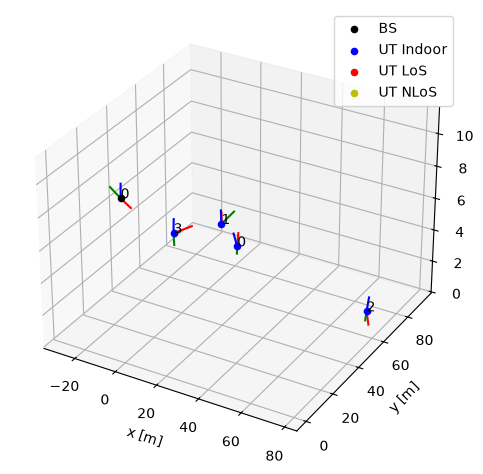

In [54]:
# Define the UT antenna array
ut_array = Antenna(polarization="single",
                   polarization_type="V",
                   antenna_pattern="omni",
                   carrier_frequency=carrier_frequency)

# Define the BS antenna array
bs_array = AntennaArray(num_rows=1,
                        num_cols=4,
                        polarization="dual",
                        polarization_type="VH",
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)

# Create channel model
channel_model = UMi(carrier_frequency=carrier_frequency,
                    o2i_model="low",
                    ut_array=ut_array,
                    bs_array=bs_array,
                    direction=direction,
                    enable_pathloss=False,
                    enable_shadow_fading=False)

# Generate the topology
topology = gen_topology(batch_size, num_ut, scenario)

# Set the topology
channel_model.set_topology(*topology)

# Visualize the topology
channel_model.show_topology()

In [55]:
# The number of transmitted streams is equal to the number of UT antennas
num_streams_per_tx = 1

# Create an RX-TX association matrix
# rx_tx_association[i,j]=1 means that receiver i gets at least one stream
# from transmitter j. Depending on the transmission direction (uplink or downlink),
# the role of UT and BS can change. However, as we have only a single
# transmitter and receiver, this does not matter:
rx_tx_association = np.zeros([1, num_ut])
rx_tx_association[0, :] = 1

# Instantiate a StreamManagement object
# This determines which data streams are determined for which receiver.
# In this simple setup, this is fairly simple. However, it can get complicated
# for simulations with many transmitters and receivers.
sm = StreamManagement(rx_tx_association, num_streams_per_tx)

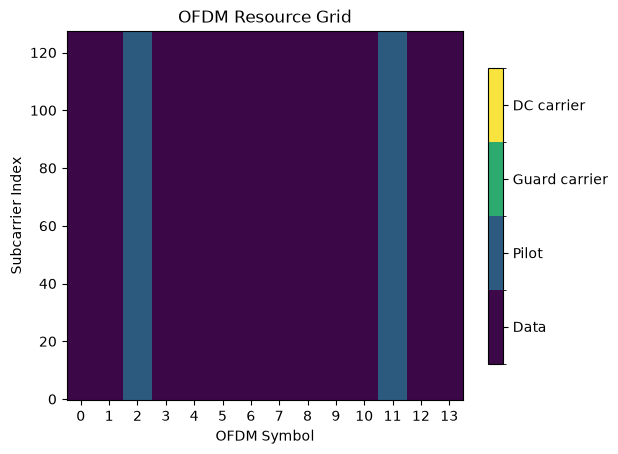

In [56]:
rg = ResourceGrid(num_ofdm_symbols=14,
                  fft_size=128,
                  subcarrier_spacing=30e3,
                  num_tx=num_ut,
                  num_streams_per_tx=num_streams_per_tx,
                  cyclic_prefix_length=20,
                  pilot_pattern="kronecker",
                  pilot_ofdm_symbol_indices=[2,11])
rg.show();

In [57]:
num_bits_per_symbol = 2 # QPSK modulation
coderate = 0.5 # The code rate
n = int(rg.num_data_symbols*num_bits_per_symbol) # Number of coded bits
k = int(n*coderate) # Number of information bits

# The binary source will create batches of information bits
binary_source = BinarySource()
qam_source = QAMSource(num_bits_per_symbol)

# The encoder maps information bits to coded bits
encoder = LDPC5GEncoder(k, n)

# The mapper maps blocks of information bits to constellation symbols
mapper = Mapper("qam", num_bits_per_symbol)

# The resource grid mapper maps symbols onto an OFDM resource grid
rg_mapper = ResourceGridMapper(rg)

# This function removes nulled subcarriers from any tensor having the shape of a resource grid
remove_nulled_scs = RemoveNulledSubcarriers(rg)

# The LS channel estimator will provide channel estimates and error variances
ls_est = LSChannelEstimator(rg, interpolation_type="nn")

# The LMMSE equalizer will provide soft symbols together with noise variance estimates
lmmse_equ = LMMSEEqualizer(rg, sm)

# The demapper produces LLR for all coded bits
demapper = Demapper("app", "qam", num_bits_per_symbol)

# The decoder provides hard-decisions on the information bits
decoder = LDPC5GDecoder(encoder, hard_out=True)

# OFDM CHannel
ofdm_channel = OFDMChannel(channel_model, rg, add_awgn=True, normalize_channel=False, return_channel=True)
channel_freq = ApplyOFDMChannel(add_awgn=True)
frequencies = subcarrier_frequencies(rg.fft_size, rg.subcarrier_spacing)

## Uplink Transmissions in the Frequency Domain

We now simulate a batch of uplink transmissions. We keep references to the estimated and actual channel frequency responses.

In [58]:
ebno_db = 10
no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate, rg)
b = binary_source([batch_size, num_ut, rg.num_streams_per_tx, encoder.k])
c = encoder(b)
x = mapper(c)
x_rg = rg_mapper(x)

a, tau = channel_model(num_time_samples=rg.num_ofdm_symbols, sampling_frequency=1/rg.ofdm_symbol_duration)
h_freq = cir_to_ofdm_channel(frequencies, a, tau, normalize=True)

y = channel_freq(x_rg, h_freq, no)
h_hat, err_var = ls_est (y, no)
x_hat, no_eff = lmmse_equ(y, h_hat, err_var, no)
llr = demapper(x_hat, no_eff)
b_hat = decoder(llr)
print("BER: {}".format(compute_ber(b, b_hat).cpu().numpy()))

BER: 0.0


### Compare Estimated and Actual Frequency Responses
We can now compare the estimated frequency responses and ground truth:

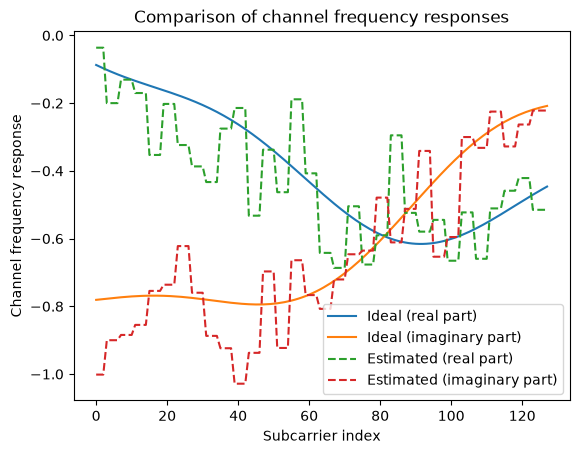

In [59]:
# In the example above, we assumed perfect CSI, i.e.,
# h_hat correpsond to the exact ideal channel frequency response.
h_perf = remove_nulled_scs(h_freq)[0,0,0,0,0,0]

# We now compute the LS channel estimate from the pilots.
h_est = h_hat[0,0,0,0,0,0]

plt.figure()
plt.plot(np.real(h_perf.cpu()))
plt.plot(np.imag(h_perf.cpu()))
plt.plot(np.real(h_est.cpu()), "--")
plt.plot(np.imag(h_est.cpu()), "--")
plt.xlabel("Subcarrier index")
plt.ylabel("Channel frequency response")
plt.legend(["Ideal (real part)", "Ideal (imaginary part)", "Estimated (real part)", "Estimated (imaginary part)"]);
plt.title("Comparison of channel frequency responses");

### Understand the Difference Between the Channel Models
Before we proceed with more advanced simulations, it is important to understand the differences
between the UMi, UMa, and RMa models. In the following code snippet, we compute the empirical cummulative
distribution function (CDF) of the condition number of the channel frequency response matrix
between all receiver and transmit antennas.

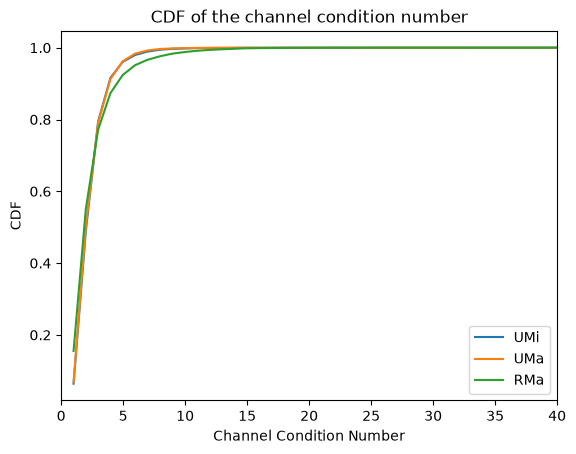

In [60]:
def cond_hist(scenario):
    """Generates a histogram of the channel condition numbers"""

    # Setup a CIR generator
    if scenario == "umi":
        channel_model = UMi(carrier_frequency=carrier_frequency,
                                      o2i_model="low",
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)
    elif scenario == "uma":
        channel_model = UMa(carrier_frequency=carrier_frequency,
                                      o2i_model="low",
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)
    elif scenario == "rma":
        channel_model = RMa(carrier_frequency=carrier_frequency,
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)

    topology = gen_topology(1024, num_ut, scenario)

    # Set the topology
    channel_model.set_topology(*topology)

    # Generate random CIR realizations
    # As we nned only a single sample in time, the sampling_frequency
    # does not matter.
    cir = channel_model(1, 1)

    # Compute the frequency response
    h = cir_to_ofdm_channel(frequencies, *cir, normalize=True)

    h = torch.squeeze(h)
    h = torch.permute(h, (0, 3, 1, 2))

    # Compute condition number
    c = np.reshape(np.linalg.cond(h.cpu().numpy()), [-1])

    # Compute normalized histogram
    hist, bins = np.histogram(c, 100, (1, 100))
    hist = hist/np.sum(hist)
    return bins[:-1], hist

plt.figure()
for cdl_model in ["umi", "uma", "rma"]:
    bins, hist = cond_hist(cdl_model)
    plt.plot(bins, np.cumsum(hist))
plt.xlim([0,40])
plt.legend(["UMi", "UMa", "RMa"]);
plt.xlabel("Channel Condition Number")
plt.ylabel("CDF")
plt.title("CDF of the channel condition number");

From the figure above, you can observe that the UMi and UMa models
are better conditioned than the RMa model. This makes
them more suitable for MIMO transmissions as we will observe in the next
section.

It is also interesting to look at the channel frequency responses of these different models, as done in the next cell:

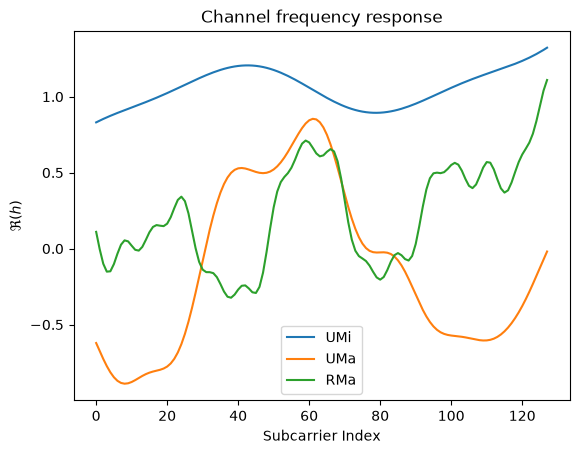

In [61]:
def freq_response(scenario):
    """Generates an example frequency response"""

    # Setup a CIR generator
    if scenario == "umi":
        channel_model = UMi(carrier_frequency=carrier_frequency,
                                      o2i_model="low",
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)
    elif scenario == "uma":
        channel_model = UMa(carrier_frequency=carrier_frequency,
                                      o2i_model="low",
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)
    elif scenario == "rma":
        channel_model = RMa(carrier_frequency=carrier_frequency,
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)

    topology = gen_topology(1, num_ut, scenario)

    # Set the topology
    channel_model.set_topology(*topology)

    # Generate random CIR realizations
    # As we nned only a single sample in time, the sampling_frequency
    # does not matter.
    cir = channel_model(1, 1)

    # Compute the frequency response
    h = cir_to_ofdm_channel(frequencies, *cir, normalize=True)
    h = h.squeeze()

    return h[0,0]

plt.figure()
for cdl_model in ["umi", "uma", "rma"]:
    h = freq_response(cdl_model)
    plt.plot(np.real(h.cpu()))
plt.legend(["UMi", "UMa", "RMa"]);
plt.xlabel("Subcarrier Index")
plt.ylabel(r"$\Re(h)$")
plt.title("Channel frequency response");

The RMa model has significantly less frequency selectivity than the other models which makes channel estimation easier.

### Setup a Sionna Block for BER simulations

In [62]:
class Model(Block):
    def __init__(self, scenario, perfect_csi=True):
        super().__init__()
        self._scenario = scenario
        self._perfect_csi = perfect_csi
        self._carrier_frequency = 3.5e9
        self._fft_size = 128
        self._subcarrier_spacing = 30e3
        self._num_ofdm_symbols = 14
        self._cyclic_prefix_length = 20
        self._pilot_ofdm_symbol_indices = [2, 11]
        self._num_bs_ant = 8
        self._num_ut = 4
        self._num_ut_ant = 1
        self._num_bits_per_symbol = 4
        self._coderate = 1.0
        self._lattice_n = 512

        self._lattice_engine = LatticeBasedEncryptor(n=self._lattice_n, verbose=False)

        bs_ut_association = np.zeros([1, self._num_ut])
        bs_ut_association[0, :] = 1
        self._rx_tx_association = bs_ut_association
        self._num_tx = self._num_ut
        self._num_streams_per_tx = self._num_ut_ant

        self._rg = ResourceGrid(num_ofdm_symbols=self._num_ofdm_symbols,
                                fft_size=self._fft_size,
                                subcarrier_spacing=self._subcarrier_spacing,
                                num_tx=self._num_tx,
                                num_streams_per_tx=self._num_streams_per_tx,
                                cyclic_prefix_length=self._cyclic_prefix_length,
                                pilot_pattern="kronecker",
                                pilot_ofdm_symbol_indices=self._pilot_ofdm_symbol_indices)

        self._sm = StreamManagement(self._rx_tx_association, self._num_streams_per_tx)

        self._ut_array = AntennaArray(num_rows=1, num_cols=1, polarization="single",
                                      polarization_type="V", antenna_pattern="omni",
                                      carrier_frequency=self._carrier_frequency)

        self._bs_array = AntennaArray(num_rows=1, num_cols=int(self._num_bs_ant/2),
                                      polarization="dual", polarization_type="cross",
                                      antenna_pattern="38.901", carrier_frequency=self._carrier_frequency)

        if self._scenario == "umi":
            self._channel_model = UMi(carrier_frequency=self._carrier_frequency, o2i_model="low",
                                      ut_array=self._ut_array, bs_array=self._bs_array,
                                      direction="uplink", enable_pathloss=False, enable_shadow_fading=False)
        elif self._scenario == "uma":
            self._channel_model = UMa(carrier_frequency=self._carrier_frequency, o2i_model="low",
                                      ut_array=self._ut_array, bs_array=self._bs_array,
                                      direction="uplink", enable_pathloss=False, enable_shadow_fading=False)
        elif self._scenario == "rma":
            self._channel_model = RMa(carrier_frequency=self._carrier_frequency, ut_array=self._ut_array,
                                      bs_array=self._bs_array, direction="uplink",
                                      enable_pathloss=False, enable_shadow_fading=False)

        self._binary_source = BinarySource()
        self._k = int(self._rg.num_data_symbols * self._num_bits_per_symbol)
        self._mapper = Mapper("qam", self._num_bits_per_symbol, dtype=torch.complex128)
        self._rg_mapper = ResourceGridMapper(self._rg, dtype=torch.complex128)

        self._ofdm_channel = OFDMChannel(self._channel_model, self._rg, add_awgn=True,
                                         normalize_channel=True, return_channel=True, dtype=torch.complex128)
        self._remove_nulled_subcarriers = RemoveNulledSubcarriers(self._rg, dtype=torch.complex128)
        self._ls_est = LSChannelEstimator(self._rg, interpolation_type="nn", dtype=torch.complex128)
        self._lmmse_equ = LMMSEEqualizer(self._rg, self._sm, dtype=torch.complex128)
        self._demapper = Demapper("app", "qam", self._num_bits_per_symbol, dtype=torch.float64)

    def babai_decode_internal(self, x_hat_reshaped):
        device = x_hat_reshaped.device
        # Force input to complex128 to match lattice precision
        x_input = x_hat_reshaped.to(dtype=torch.complex128)
        R = self._lattice_engine.R.to(device=device, dtype=torch.complex128)
        R_inv = torch.linalg.pinv(R)
        B_inv = self._lattice_engine.B_inv.to(device=device, dtype=torch.complex128)

        Y = torch.matmul(x_input, R_inv.T)
        Y_integer = torch.round(Y.real) + 1j * torch.round(Y.imag)

        lattice_point = torch.matmul(Y_integer, R.T)
        S_hat = torch.matmul(lattice_point, B_inv.T)
        return S_hat

    def new_topology(self, batch_size):
        topology = gen_topology(batch_size, self._num_ut, self._scenario, min_ut_velocity=0.0, max_ut_velocity=0.0)
        self._channel_model.set_topology(*topology)

    def call(self, batch_size, ebno_db):
        self.new_topology(batch_size)
        no = ebnodb2no(ebno_db, self._num_bits_per_symbol, self._coderate, self._rg)
        b = self._binary_source([batch_size, self._num_tx, self._num_streams_per_tx, self._k])

        x = self._mapper(b)
        x_shape = x.shape
        x_reshaped = torch.reshape(x, (-1, self._lattice_n))
        # Ensure encryption uses correct device and dtype
        self._lattice_engine.B = self._lattice_engine.B.to(device=x.device, dtype=torch.complex128)
        x_enc_blocks = self._lattice_engine.encrypt(x_reshaped.to(torch.complex128))
        x_enc = torch.reshape(x_enc_blocks, x_shape)

        x_rg = self._rg_mapper(x_enc)
        y, h = self._ofdm_channel(x_rg, no)

        if self._perfect_csi:
            h_hat = self._remove_nulled_subcarriers(h)
            err_var = torch.tensor(0.0, dtype=torch.complex128, device=y.device)
        else:
            h_hat, err_var = self._ls_est(y, no)

        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no)

        x_hat_shape = x_hat.shape
        x_hat_reshaped = torch.reshape(x_hat, (-1, self._lattice_n))
        x_dec_lattice_blocks = self.babai_decode_internal(x_hat_reshaped)
        x_dec_lattice = torch.reshape(x_dec_lattice_blocks, x_hat_shape)

        x_dec = qam16_lattice_to_normalized(x_dec_lattice)
        llr = self._demapper(x_dec.to(torch.complex128), no_eff.to(torch.float64))
        b_hat = torch.where(llr > 0, torch.tensor(1.0, dtype=torch.float64, device=llr.device), torch.tensor(0.0, dtype=torch.float64, device=llr.device))

        return b, b_hat

If you do not want to run the simulations (which can take quite some time) yourself, you can skip the next cell and simply look at the results in the next cell.

In [63]:
SIMS = {
    "ebno_db" : list(np.arange(-5, 17, 2.0)),
    "scenario" : ["umi", "uma", "rma"],
    "perfect_csi" : [True, False],
    "ber" : [],
    "bler" : [],
    "duration" : None,
    "batch_size" : 64
}

start = time.time()

for scenario in SIMS["scenario"]:
    for perfect_csi in SIMS["perfect_csi"]:

        model = Model(scenario=scenario,
                      perfect_csi=perfect_csi)
        if torch.cuda.is_available():
            model.cuda()

        model._channel_model.allocate_topology_tensors(batch_size=SIMS["batch_size"], num_bs=1, num_ut=model._num_ut)

        ber, bler = sim_ber(model,
                            SIMS["ebno_db"],
                            batch_size=SIMS["batch_size"],
                            max_mc_iter=100,
                            num_target_block_errors=100,
                            target_bler=1e-3,
                            compile_mode=None
                            )

        SIMS["ber"].append(list(ber.cpu().numpy()))
        SIMS["bler"].append(list(bler.cpu().numpy()))

SIMS["duration" ] = time.time() - start

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -5.0 | 4.9939e-01 | 1.0000e+00 |      785473 |     1572864 |          256 |         256 |         1.6 |reached target block errors
     -3.0 | 5.0029e-01 | 1.0000e+00 |      786881 |     1572864 |          256 |         256 |         1.5 |reached target block errors
     -1.0 | 5.0042e-01 | 1.0000e+00 |      787090 |     1572864 |          256 |         256 |         1.5 |reached target block errors
      1.0 | 5.0060e-01 | 1.0000e+00 |      787376 |     1572864 |          256 |         256 |         1.5 |reached target block errors
      3.0 | 4.9986e-01 | 1.0000e+00 |      786216 |     1572864 |          256 |         256 |         1.5 |reached target block errors
      5.0 | 4.9975e-01 | 1.0000e+00 |      786032 |     1572864 |

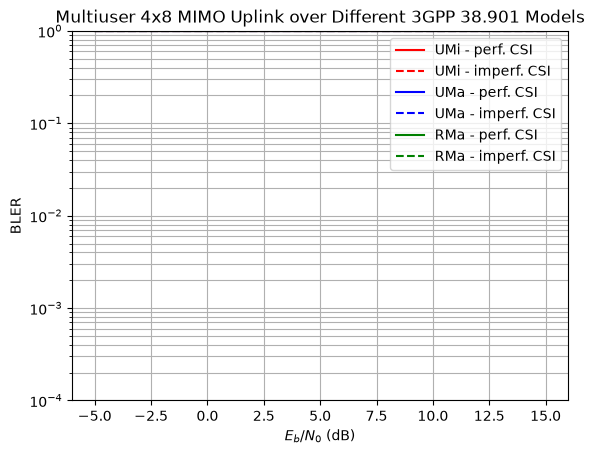

In [64]:
plt.figure()
plt.xlabel(r"$E_b/N_0$ (dB)")
plt.ylabel("BLER")
plt.grid(which="both")

i=0
legend = []
for scenario in SIMS["scenario"]:
    for perfect_csi in SIMS["perfect_csi"]:
        if scenario=="umi":
            r = "r"
            t = "UMi"
        elif scenario=="uma":
            r = "b"
            t = "UMa"
        else:
            r = "g"
            t = "RMa"
        if perfect_csi:
            r += "-"
        else:
            r += "--"

        plt.semilogy(SIMS["ebno_db"], SIMS["bler"][i], r);
        s = "{} - {} CSI".format(t,"perf." if perfect_csi else "imperf.")

        legend.append(s)
        i += 1
plt.legend(legend)
plt.ylim([1e-4, 1])
plt.title("Multiuser 4x8 MIMO Uplink over Different 3GPP 38.901 Models");

Due to the worse channel conditioning, the RMa model achieves the worst performance with perfect CSI. However, as a result of the smaller frequency selectivity, imperfect channel estimation only leads to an almost constant 6dB performace loss. For the UMI and UMa models, the used channel estimator with nearest-neighbor interpolation is not accurate enough so that the BER curves saturate at high SNR. This could, for example, be circumvented with another interpolation method (e.g., [linear interpolation with time averaging](https://nvlabs.github.io/sionna/phy/api/ofdm/sionna.phy.ofdm.LinearInterpolator.html)) or a different pilot pattern.